In [2]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
for DATA_DIR in ["/content", "/content/data", "data", "."]:
    if os.path.exists(f"{DATA_DIR}/intern_learning_history.csv"):
        break
print("Reading from:", DATA_DIR)

history = pd.read_csv(f"{DATA_DIR}/intern_learning_history.csv")
courses = pd.read_csv(f"{DATA_DIR}/courses_clean.csv")
interns = pd.read_csv(f"{DATA_DIR}/interns.csv") if os.path.exists(f"{DATA_DIR}/interns.csv") else None

print(history.shape, courses.shape)
history.head()

Reading from: /content
(24059, 11) (1000, 10)


,intern_id,intern_name,main_interest,course_id,course_title,category,level,duration_hours,rating,completion_pct,completed
0,0,Intern_000,Information Technology,3,Technical Support Fundamentals,Information Technology,Intermediate,21.0,4,72,0
1,0,Intern_000,Information Technology,12,IBM Data Science Professional Certificate,Data Science,Advanced,100.0,4,63,0
2,0,Intern_000,Information Technology,20,Google Cloud Fundamentals: Core Infrastructure,Information Technology,Beginner,8.0,4,70,0
3,0,Intern_000,Information Technology,41,Operating Systems and You: Becoming a Power User,Information Technology,Intermediate,33.0,4,43,0
4,0,Intern_000,Information Technology,45,System Administration and IT Infrastructure S...,Information Technology,Intermediate,25.0,3,60,0


Interns: 800 | Courses: 1000 | Ratings: 24059 | Sparsity: 97.0%
Missing values: 0


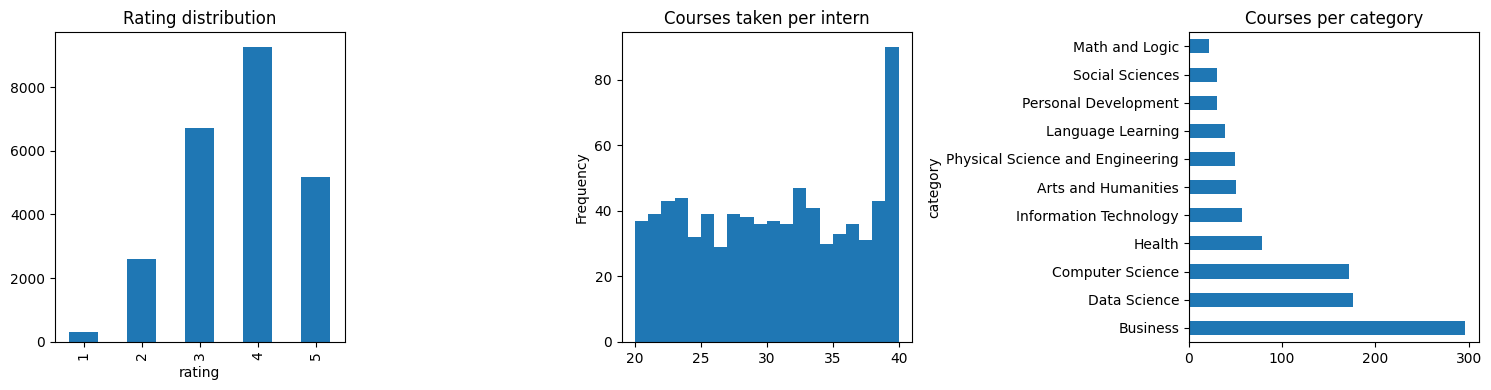

In [3]:
n_interns, n_courses = history.intern_id.nunique(), history.course_id.nunique()
sparsity = 1 - len(history) / (n_interns * n_courses)
print(f"Interns: {n_interns} | Courses: {n_courses} | Ratings: {len(history)} | Sparsity: {sparsity:.1%}")
print("Missing values:", history[["intern_id", "course_id", "rating"]].isna().sum().sum())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
history.rating.value_counts().sort_index().plot.bar(ax=ax[0], title="Rating distribution")
history.groupby("intern_id").size().plot.hist(bins=20, ax=ax[1], title="Courses taken per intern")
courses.category.value_counts().plot.barh(ax=ax[2], title="Courses per category")
plt.tight_layout(); plt.show()

In [4]:
intern_ids = np.sort(history.intern_id.unique())
course_ids = np.sort(history.course_id.unique())
u_map = {v: k for k, v in enumerate(intern_ids)}
c_map = {v: k for k, v in enumerate(course_ids)}

df = history[["intern_id", "course_id", "rating"]].copy()
df["u"] = df.intern_id.map(u_map)
df["c"] = df.course_id.map(c_map)

rng = np.random.default_rng(42)
test_mask = rng.random(len(df)) < 0.20
train, test = df[~test_mask].reset_index(drop=True), df[test_mask].reset_index(drop=True)
print("Train:", len(train), "| Test:", len(test))

Train: 19251 | Test: 4808


In [5]:
def rmse(y, p): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

global_mean = train.rating.mean()
course_mean = train.groupby("c").rating.mean()

rmse_global = rmse(test.rating, np.full(len(test), global_mean))
rmse_course = rmse(test.rating, test.c.map(course_mean).fillna(global_mean))
print(f"Global-mean RMSE: {rmse_global:.4f}")
print(f"Course-mean RMSE: {rmse_course:.4f}")

Global-mean RMSE: 0.9623
Course-mean RMSE: 0.9436


In [6]:
class MatrixFactorization:
    def __init__(self, n_factors=10, lr=0.01, reg=0.1, epochs=30, seed=42):
        self.k, self.lr, self.reg, self.epochs, self.seed = n_factors, lr, reg, epochs, seed

    def fit(self, u, c, r, n_users, n_items, verbose=False):
        rng = np.random.default_rng(self.seed)
        self.mu = r.mean()
        self.bu, self.bi = np.zeros(n_users), np.zeros(n_items)
        self.P = rng.normal(0, 0.1, (n_users, self.k))
        self.Q = rng.normal(0, 0.1, (n_items, self.k))
        for ep in range(self.epochs):
            for x in rng.permutation(len(r)):
                a, b = u[x], c[x]
                err = r[x] - (self.mu + self.bu[a] + self.bi[b] + self.P[a] @ self.Q[b])
                self.bu[a] += self.lr * (err - self.reg * self.bu[a])
                self.bi[b] += self.lr * (err - self.reg * self.bi[b])
                pa = self.P[a].copy()
                self.P[a] += self.lr * (err * self.Q[b] - self.reg * self.P[a])
                self.Q[b] += self.lr * (err * pa - self.reg * self.Q[b])
            if verbose and (ep + 1) % 10 == 0:
                print(f"epoch {ep+1}: train RMSE {rmse(r, self.predict(u, c)):.4f}")
        return self

    def predict(self, u, c):
        u, c = np.asarray(u), np.asarray(c)
        return np.clip(self.mu + self.bu[u] + self.bi[c] + np.sum(self.P[u] * self.Q[c], axis=1), 1, 5)

    def predict_all(self, u):          # scores for every course for one intern
        return np.clip(self.mu + self.bu[u] + self.bi + self.Q @ self.P[u], 1, 5)

U, C = len(intern_ids), len(course_ids)
model = MatrixFactorization().fit(train.u.values, train.c.values, train.rating.values.astype(float), U, C, verbose=True)
print(f"Test RMSE (rating prediction): {rmse(test.rating, model.predict(test.u.values, test.c.values)):.4f}")

epoch 10: train RMSE 0.8071
epoch 20: train RMSE 0.7883
epoch 30: train RMSE 0.7639
Test RMSE (rating prediction): 0.8798


   n_factors  test_rmse
0          5   0.878411
1         10   0.879850
2         20   0.879065
3         40   0.880205


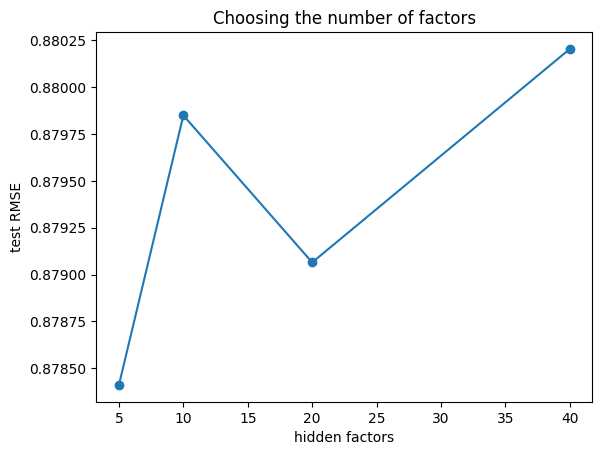

Best: 5 factors, test RMSE 0.8784 (course-mean baseline: 0.9436)


In [7]:
results = []
for k in [5, 10, 20, 40]:
    m = MatrixFactorization(n_factors=k).fit(train.u.values, train.c.values, train.rating.values.astype(float), U, C)
    results.append((k, rmse(test.rating, m.predict(test.u.values, test.c.values))))
res = pd.DataFrame(results, columns=["n_factors", "test_rmse"])
print(res)

plt.plot(res.n_factors, res.test_rmse, marker="o"); plt.xlabel("hidden factors"); plt.ylabel("test RMSE")
plt.title("Choosing the number of factors"); plt.show()

best_k = int(res.loc[res.test_rmse.idxmin(), "n_factors"])
model = MatrixFactorization(n_factors=best_k).fit(train.u.values, train.c.values, train.rating.values.astype(float), U, C)
rmse_mf = rmse(test.rating, model.predict(test.u.values, test.c.values))
print(f"Best: {best_k} factors, test RMSE {rmse_mf:.4f} (course-mean baseline: {rmse_course:.4f})")

In [8]:
class ImplicitALS:
    def __init__(self, n_factors=10, alpha=10, reg=0.1, iters=15, seed=0):
        self.k, self.alpha, self.reg, self.iters, self.seed = n_factors, alpha, reg, iters, seed

    def _solve(self, F, groups, other_idx, conf, n_out):
        k, FtF = self.k, F.T @ F
        out = np.zeros((n_out, k))
        for a, ix in groups.items():
            Fo, c = F[other_idx[ix]], conf[ix]
            A = FtF + (Fo.T * (c - 1)) @ Fo + self.reg * np.eye(k)
            out[a] = np.linalg.solve(A, Fo.T @ c)
        return out

    def fit(self, u, c, engagement, n_users, n_items):
        rng = np.random.default_rng(self.seed)
        conf = 1 + self.alpha * np.asarray(engagement)
        by_u = pd.Series(np.arange(len(u))).groupby(u).indices
        by_c = pd.Series(np.arange(len(c))).groupby(c).indices
        self.X = rng.normal(0, 0.1, (n_users, self.k))
        self.Y = rng.normal(0, 0.1, (n_items, self.k))
        for _ in range(self.iters):
            self.X = self._solve(self.Y, by_u, c, conf, n_users)
            self.Y = self._solve(self.X, by_c, u, conf, n_items)
        return self

    def predict_all(self, u):          # preference score for every course
        return self.Y @ self.X[u]

# positives = courses the intern took and did not dislike (rating >= 3)
completion = history.completion_pct.values
df["completion"] = completion
df["engagement"] = (df.rating / 5) * (df.completion / 100)
train = df[~test_mask].reset_index(drop=True)
test = df[test_mask].reset_index(drop=True)
pos = train[train.rating >= 3]

als_results = []
for k in [5, 10, 20]:
    als = ImplicitALS(n_factors=k).fit(pos.u.values, pos.c.values, pos.engagement.values, U, C)
    als_results.append((k, als))
print("trained ALS models for k =", [k for k, _ in als_results])

trained ALS models for k = [5, 10, 20]


Best ranking model: ALS k=10


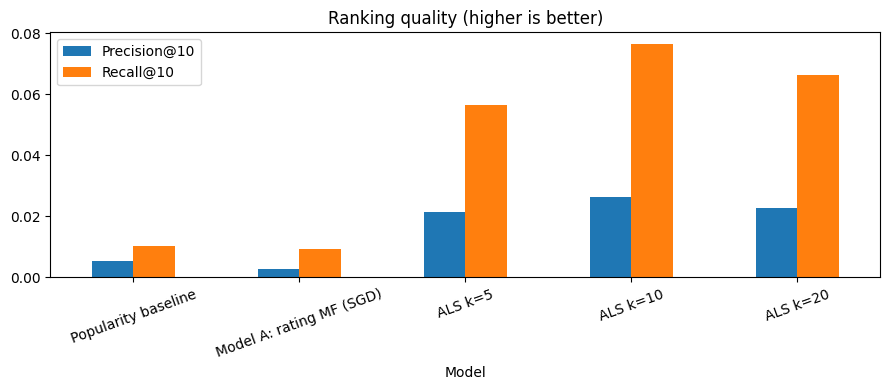

In [11]:
K = 10
train_seen = train.groupby("u").c.apply(set).to_dict()
test_liked = test[test.rating >= 4].groupby("u").c.apply(set).to_dict()
popularity = train.groupby("c").size().reindex(range(C), fill_value=0).values

def evaluate(score_fn):
    prec, rec = [], []
    for u, liked in test_liked.items():
        scores = score_fn(u).astype(float).copy()
        scores[list(train_seen.get(u, []))] = -np.inf          # never recommend already-taken courses
        top = np.argpartition(-scores, K)[:K]
        hits = len(set(top) & liked)
        prec.append(hits / K); rec.append(hits / len(liked))
    return np.mean(prec), np.mean(rec)

rank_rows = [("ALS k=%d" % k, *evaluate(lambda u, a=a: a.predict_all(u))) for k, a in als_results]
best_name, _, _ = max(rank_rows, key=lambda r: r[1])
best_als = dict((f"ALS k={k}", a) for k, a in als_results)[best_name]

summary = pd.DataFrame(
    [("Popularity baseline", *evaluate(lambda u: popularity)),
     ("Model A: rating MF (SGD)", *evaluate(model.predict_all))] + rank_rows,
    columns=["Model", f"Precision@{K}", f"Recall@{K}"]).round(4)
print("Best ranking model:", best_name)

summary.set_index("Model")[[f"Precision@{K}", f"Recall@{K}"]].plot.bar(rot=20, title="Ranking quality (higher is better)", figsize=(9, 4))
plt.tight_layout(); plt.show()

In [12]:
final_rating = MatrixFactorization(n_factors=best_k).fit(df.u.values, df.c.values, df.rating.values.astype(float), U, C)
pos_all = df[df.rating >= 3]
final_rank = ImplicitALS(n_factors=int(best_name.split("=")[1])).fit(
    pos_all.u.values, pos_all.c.values, pos_all.engagement.values, U, C)

taken_all = df.groupby("u").c.apply(set).to_dict()
course_lookup = courses.set_index("course_id")
level_order = {"Beginner": 0, "Intermediate": 1, "Advanced": 2}

def recommend_path(intern_id, n=8):
    u = u_map[intern_id]
    scores = final_rank.predict_all(u).copy()
    scores[list(taken_all.get(u, []))] = -np.inf
    top = np.argsort(-scores)[:n]
    out = pd.DataFrame({"course_id": course_ids[top],
                        "match_score": scores[top].round(3),
                        "expected_rating": final_rating.predict_all(u)[top].round(2)})
    out = out.join(course_lookup[["course_title", "category", "level", "duration_hours", "url"]], on="course_id")
    out["level_rank"] = out.level.map(level_order)
    out = out.sort_values(["level_rank", "match_score"], ascending=[True, False]).drop(columns="level_rank")
    out.insert(0, "step", range(1, len(out) + 1))
    return out.reset_index(drop=True)

demo_intern = int(intern_ids[0])
if interns is not None:
    print(interns[interns.intern_id == demo_intern][["intern_id", "main_interest", "second_interest"]].to_string(index=False))
recommend_path(demo_intern)

,step,course_id,match_score,expected_rating,course_title,category,level,duration_hours,url
0,1,549,0.559,3.99,"Information Systems Auditing, Controls and Ass...",Information Technology,Beginner,8.0,https://www.coursera.org/learn/information-sys...
1,2,389,0.522,3.38,Data-driven Decision Making,Data Science,Beginner,9.0,https://www.coursera.org/learn/decision-making
2,3,52,0.517,3.54,Data Science Methodology,Data Science,Beginner,8.0,https://www.coursera.org/learn/data-science-me...
3,4,33,0.590,3.91,Sequence Models,Data Science,Intermediate,37.0,https://www.coursera.org/learn/nlp-sequence-mo...
4,5,51,0.574,4.34,IT Security: Defense against the digital dark...,Information Technology,Intermediate,31.0,https://www.coursera.org/learn/it-security
5,6,689,0.520,3.85,Google Cloud Digital Leader Training Professio...,Information Technology,Intermediate,20.0,https://www.coursera.org/professional-certific...
6,7,25,0.517,4.04,Convolutional Neural Networks,Data Science,Intermediate,36.0,https://www.coursera.org/learn/convolutional-n...
7,8,408,0.516,3.67,Introduction to Probability and Data with R,Data Science,Intermediate,14.0,https://www.coursera.org/learn/probability-intro


In [13]:
if interns is not None:
    hits = []
    for _, row in interns.sample(100, random_state=1).iterrows():
        rec = recommend_path(int(row.intern_id))
        hits.append((rec.category == row.main_interest).mean())
    chance = (courses.category.value_counts(normalize=True) ** 2).sum()
    print(f"Share of recommended courses in the intern's main interest: {np.mean(hits):.1%}")
    print(f"Share if courses were picked at random: about {chance:.1%}")

In [14]:
def recommend_new_intern(interest, n=8):
    pool = courses[courses.category == interest].copy()
    pool["score"] = pool.rating + 0.1 * np.log10(pool.num_viewers + 1)
    pool = pool.sort_values("score", ascending=False).head(n)
    pool["level_rank"] = pool.level.map(level_order)
    pool = pool.sort_values(["level_rank", "score"], ascending=[True, False])
    pool.insert(0, "step", range(1, len(pool) + 1))
    return pool[["step", "course_title", "category", "level", "rating", "url"]].reset_index(drop=True)

recommend_new_intern("Data Science")

,step,course_title,category,level,rating,url
0,1,Neural Networks and Deep Learning,Data Science,Intermediate,4.9,https://www.coursera.org/learn/neural-networks...
1,2,Improving Deep Neural Networks: Hyperparameter...,Data Science,Intermediate,4.9,https://www.coursera.org/learn/deep-neural-net...
2,3,Convolutional Neural Networks,Data Science,Intermediate,4.9,https://www.coursera.org/learn/convolutional-n...
3,4,Machine Learning Specialization,Data Science,Intermediate,4.9,https://www.coursera.org/specializations/machi...
4,5,Supervised Machine Learning: Regression and Cl...,Data Science,Intermediate,4.9,https://www.coursera.org/learn/machine-learning
5,6,Deep Learning Specialization,Data Science,Advanced,4.9,https://www.coursera.org/specializations/deep-...
6,7,Análisis de Datos de Google Professional Certi...,Data Science,Advanced,5.0,https://www.coursera.org/professional-certific...
7,8,Google Data Analytics Professional Certificate,Data Science,Advanced,4.8,https://www.coursera.org/professional-certific...


In [15]:
all_recs = []
for iid in intern_ids:
    r = recommend_path(int(iid)); r.insert(0, "intern_id", int(iid)); all_recs.append(r)
all_recs = pd.concat(all_recs, ignore_index=True)
all_recs.to_csv("recommendations.csv", index=False)
print(all_recs.shape)

try:
    from google.colab import files
    files.download("recommendations.csv")
except ImportError:
    pass
all_recs.head(10)

(6400, 10)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,intern_id,step,course_id,match_score,expected_rating,course_title,category,level,duration_hours,url
0,0,1,549,0.559,3.99,"Information Systems Auditing, Controls and Ass...",Information Technology,Beginner,8.0,https://www.coursera.org/learn/information-sys...
1,0,2,389,0.522,3.38,Data-driven Decision Making,Data Science,Beginner,9.0,https://www.coursera.org/learn/decision-making
2,0,3,52,0.517,3.54,Data Science Methodology,Data Science,Beginner,8.0,https://www.coursera.org/learn/data-science-me...
3,0,4,33,0.590,3.91,Sequence Models,Data Science,Intermediate,37.0,https://www.coursera.org/learn/nlp-sequence-mo...
4,0,5,51,0.574,4.34,IT Security: Defense against the digital dark...,Information Technology,Intermediate,31.0,https://www.coursera.org/learn/it-security
5,0,6,689,0.520,3.85,Google Cloud Digital Leader Training Professio...,Information Technology,Intermediate,20.0,https://www.coursera.org/professional-certific...
6,0,7,25,0.517,4.04,Convolutional Neural Networks,Data Science,Intermediate,36.0,https://www.coursera.org/learn/convolutional-n...
7,0,8,408,0.516,3.67,Introduction to Probability and Data with R,Data Science,Intermediate,14.0,https://www.coursera.org/learn/probability-intro
8,1,1,8,0.678,3.53,Python Data Structures,Computer Science,Intermediate,19.0,https://www.coursera.org/learn/python-data
9,1,2,73,0.623,3.42,"HTML, CSS, and Javascript for Web Developers",Computer Science,Intermediate,40.0,https://www.coursera.org/learn/html-css-javasc...
